# EDA — Bivariate en multivariate analyse

Na de univariate analyse — waarbij je elke variabele afzonderlijk bekeek — kijk je nu naar de **relaties tussen variabelen**.

Deze notebook behandelt:
- **Correlatiematrix** en heatmap
- **Scatter plot** per categorie
- **Boxplot** van numerieke variabele per categorische variabele
- **Pairplot** voor een globaal overzicht
- Multicollineariteit opsporen

We werken verder met de **Titanic-dataset**.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import seaborn as sns

sns.set_theme(style="whitegrid")

df = sns.load_dataset("titanic").copy()

# Basic cleaning: fill missing ages with median
df["age"] = df["age"].fillna(df["age"].median())

df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## Correlatiematrix

De **correlatiecoëfficiënt** (Pearson) meet de **lineaire** samenhang tussen twee numerieke variabelen:
- **+1**: perfecte positieve correlatie
- **0**: geen lineaire correlatie
- **−1**: perfecte negatieve correlatie

⚠️ Correlatie ≠ causaliteit!

In [2]:
# Select numeric columns and compute correlation matrix
numeric_cols = df.select_dtypes(include="number")
corr = numeric_cols.corr().round(2)
print(corr)

          survived  pclass   age  sibsp  parch  fare
survived      1.00   -0.34 -0.06  -0.04   0.08  0.26
pclass       -0.34    1.00 -0.34   0.08   0.02 -0.55
age          -0.06   -0.34  1.00  -0.23  -0.17  0.10
sibsp        -0.04    0.08 -0.23   1.00   0.41  0.16
parch         0.08    0.02 -0.17   0.41   1.00  0.22
fare          0.26   -0.55  0.10   0.16   0.22  1.00


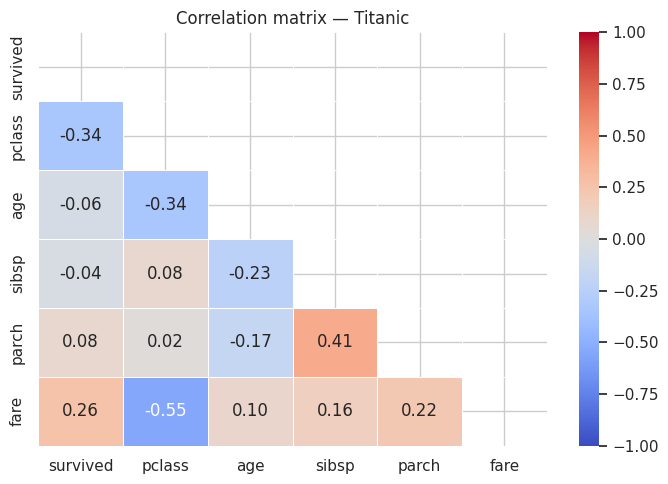

In [3]:
# Visualise as a heatmap
fig, ax = plt.subplots(figsize=(7, 5))
mask = np.triu(np.ones_like(corr, dtype=bool))  # hide upper triangle (duplicates)

sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    ax=ax,
)
ax.set_title("Correlation matrix — Titanic")
plt.tight_layout()
plt.show()

In [4]:
# Which variables correlate most strongly with 'survived'?
corr_survived = corr["survived"].drop("survived").abs().sort_values(ascending=False)
print("Correlation with 'survived' (absolute):")
print(corr_survived)

Correlation with 'survived' (absolute):
pclass    0.34
fare      0.26
parch     0.08
age       0.06
sibsp     0.04
Name: survived, dtype: float64


## Scatter plot — relatie tussen twee numerieke variabelen

In [5]:
# Age vs. fare, coloured by class
fig = px.scatter(
    df,
    x="age",
    y="fare",
    color="pclass",
    opacity=0.6,
    hover_data=["sex", "survived"],
    title="Age vs. ticket price per class",
    labels={"age": "Age (years)", "fare": "Price (£)", "pclass": "Class"},
    color_continuous_scale="Viridis",
)
fig.show()

## Boxplot — numeriek per categorie

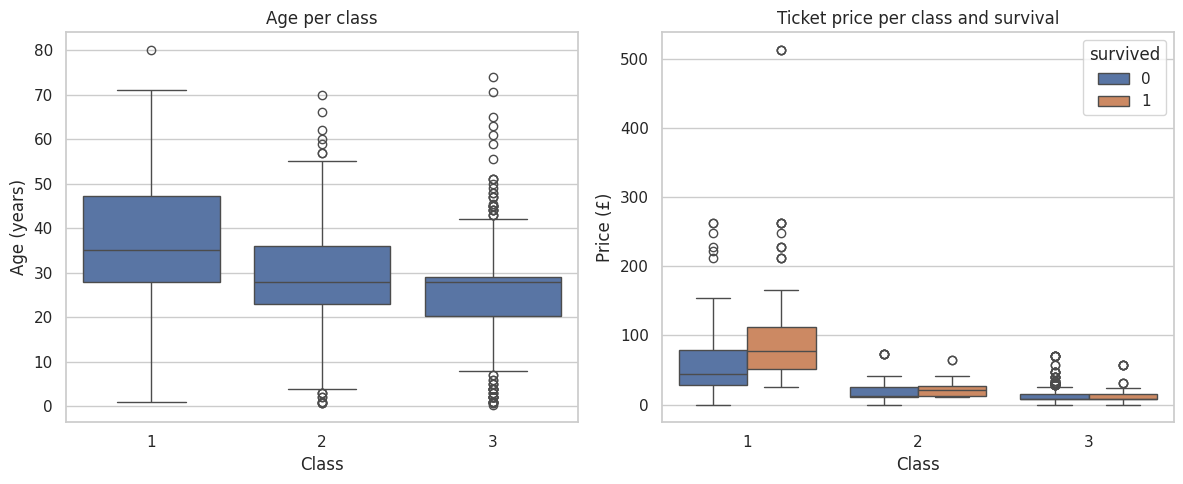

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Age per class
sns.boxplot(data=df, x="pclass", y="age", ax=axes[0])
axes[0].set_title("Age per class")
axes[0].set_xlabel("Class")
axes[0].set_ylabel("Age (years)")

# Ticket price per class, hue on survival
sns.boxplot(data=df, x="pclass", y="fare", hue="survived", ax=axes[1])
axes[1].set_title("Ticket price per class and survival")
axes[1].set_xlabel("Class")
axes[1].set_ylabel("Price (£)")

plt.tight_layout()
plt.show()

## Categorische variabele vs. doelvariabele

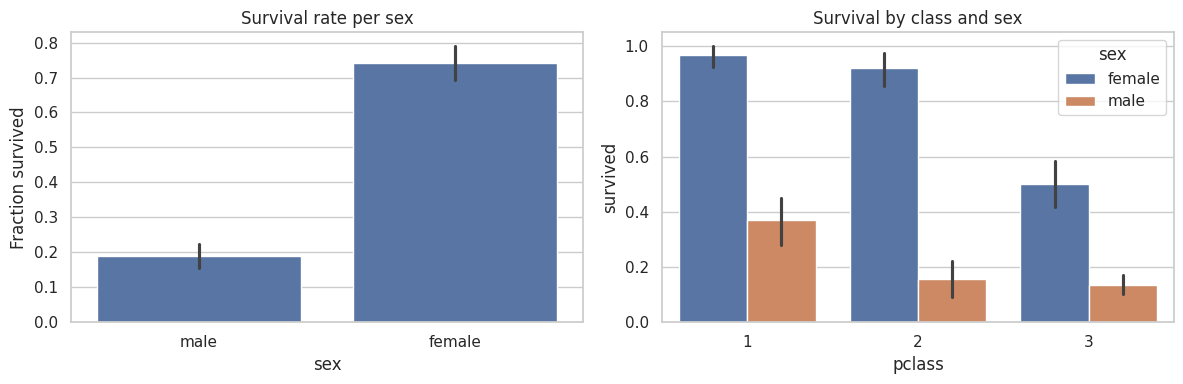

In [7]:
# Survival rate by sex and class
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Survival rate per sex
sns.barplot(data=df, x="sex", y="survived", ax=axes[0])
axes[0].set_title("Survival rate per sex")
axes[0].set_ylabel("Fraction survived")

# Survival rate per class and sex
sns.barplot(data=df, x="pclass", y="survived", hue="sex", ax=axes[1])
axes[1].set_title("Survival by class and sex")

plt.tight_layout()
plt.show()

## Pairplot — alle variabelen in één overzicht

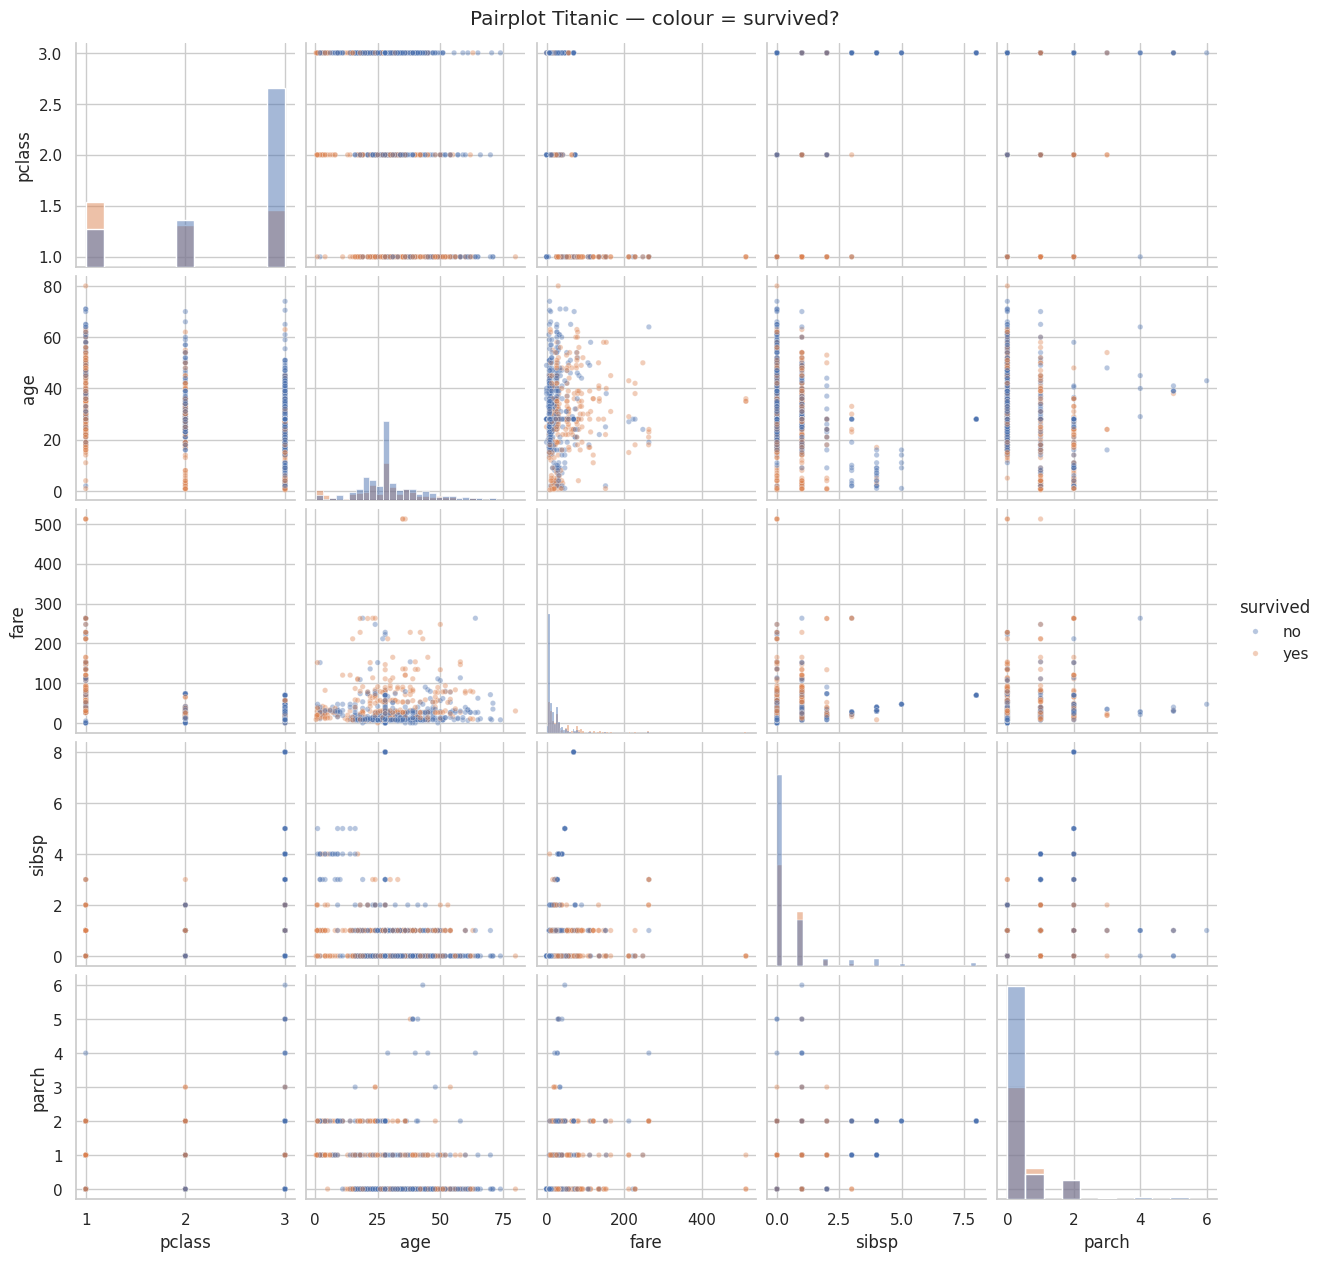

In [8]:
# Select relevant columns for the pairplot
subset = df[["survived", "pclass", "age", "fare", "sibsp", "parch"]].copy()
subset["survived"] = subset["survived"].map({0: "no", 1: "yes"})

g = sns.pairplot(
    subset,
    hue="survived",
    plot_kws={"alpha": 0.4, "s": 15},
    diag_kind="hist",
)
g.fig.suptitle("Pairplot Titanic — colour = survived?", y=1.01)
plt.show()

## Multicollineariteit opsporen

**Multicollineariteit** treedt op wanneer twee variabelen sterk met elkaar correleren. Dit kan problemen geven bij bepaalde modellen. In de EDA-fase noteer je welke paren een hoge correlatie hebben (|r| > 0.5).

In [9]:
# Find highly correlated pairs (threshold = 0.5, excluding diagonal)
threshold = 0.5
high_corr = corr.where(np.tril(np.ones(corr.shape), k=-1).astype(bool)).stack().reset_index()
high_corr.columns = ["variable_1", "variable_2", "correlation"]
high_corr = high_corr[high_corr["correlation"].abs() > threshold].sort_values(
    "correlation", key=abs, ascending=False
)
print(high_corr.to_string(index=False))

variable_1 variable_2  correlation
      fare     pclass        -0.55


---

## Oefeningen

Gebruik de **Penguins-dataset**: `sns.load_dataset("penguins")`.

In [10]:
penguins = sns.load_dataset("penguins").dropna()

**Oefening 1** — Bereken de correlatiematrix voor alle numerieke kolommen van de Penguins-dataset. Visualiseer als heatmap (gebruik de onderste driehoek). Welke twee variabelen zijn het sterkst gecorreleerd?

In [11]:
# your solution here

**Oefening 2** — Maak een interactieve scatter plot (Plotly) van `bill_length_mm` vs. `body_mass_g`, met kleur per `species` en grootte proportioneel aan `flipper_length_mm`. Beschrijf in een markdown-cel wat je opvalt.

In [12]:
# your solution here

*Description:*

**Oefening 3** — Maak een boxplot van `body_mass_g` per `island`, met `hue="sex"`. Op welk eiland zijn de pinguïns het zwaarst? Is er een duidelijk verschil tussen mannetjes en vrouwtjes?

In [13]:
# your solution here

**Oefening 4** — Maak een pairplot voor de Penguins-dataset met `hue="species"`. Identificeer in een markdown-cel:
- Welk kenmerkenpaar het meest onderscheidend is voor de drie species
- Welke species het meest op elkaar lijken

In [14]:
# your solution here